Important packages to import 


In [7]:
# importing packages
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
import numpy as np
import scipy.io
import os
import numpy as np
from scipy.stats import pearsonr
import lime 
import lime.lime_tabular
import numpy as np 
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import shap

### Loading the dataset


## 1. Data Preparation
In this step, we perform the following:
* **Load**: Import data from the `.mat` file.
* **Inspect**: Check the shape of `X` and `y`.
* **Split**: Use `train_test_split` to create training and testing sets.


In [8]:

# Define the base path (adjust path if needed)
base_dir = os.path.join(os.path.expanduser("~"), "Desktop", "TEAM - Dataset", "data")

# Load only the first dataset
data = scipy.io.loadmat(os.path.join(base_dir, "1", "data.mat"))

# Extract variabl
X, y = data['X'], data['y']

print(f"Loaded successfully. Features shape: {X.shape}, Labels shape: {y.shape}")

Loaded successfully. Features shape: (198, 33), Labels shape: (198, 1)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y.ravel(), test_size = 0.2, random_state = 42)


## 2. Model Training & Performance
**Procedure:** Trained `LogisticRegression` and `RandomForestClassifier` on the $80\%$ training split and evaluated both on the original dataset.

In [13]:
LR_model = LogisticRegression(max_iter = 1000)
# fit the model 
LR_model.fit(X_train, y_train)
# corss validate on the 80% training data

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [14]:
RF_model = RandomForestClassifier(n_estimators=100, random_state=42)
# fit the model 
RF_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [7]:
y_pred_proba_orginal = LR_model.predict_proba(X)[:,1]
auc_score = roc_auc_score(y,y_pred_proba_orginal)
print(f"AUC score of Linera regression model on orginal instances: {auc_score: .4f}")

AUC score of Linera regression model on orginal instances:  0.8828


In [8]:
y_pred_proba_original = RF_model.predict_proba(X)[:,1]
auc_score = roc_auc_score(y,y_pred_proba_original)
print(f"AUC score of Random forest model on orginal instances: {auc_score:.4f}")

AUC score of Random forest model on orginal instances: 0.9679


**Performance Summary:**
| Model | AUC Score |
| :--- | :--- |
| Logistic Regression | **0.8828** |
| Random Forest | **0.9679** |

## 3. Feature Importance Analysis
**Procedure:** Calculating `SHAP` and `LIME` values for the `LogisticRegression` model to interpret feature contributions.

In [ ]:
*** Learning *** why do we use only x_trian on the shap and lime 
to avoid biased explanation if it is exposed to the whole dataset 
we want the explainer reflect the how the model behaves 

In [31]:
import shap

# 1. Initialize the Explainer using the training set
explainer = shap.Explainer(LR_model, X_train)

# 2. Calculate SHAP values for your data
lr_shap = explainer(X)

Background dataset has 158 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=158 when initializing the masker.


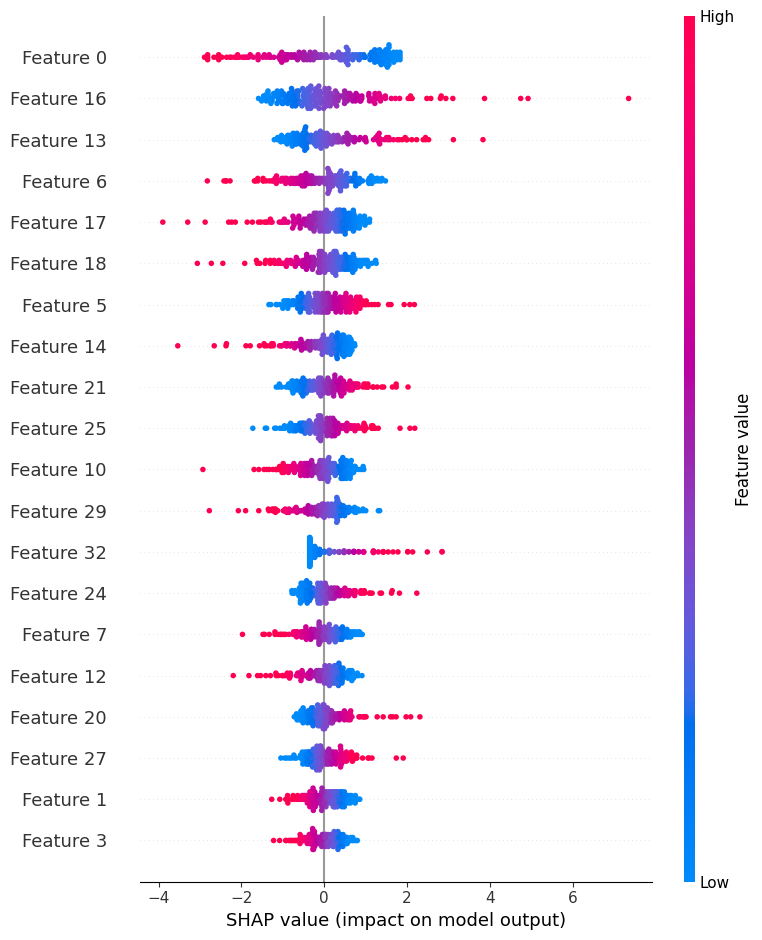

In [18]:
# This generates the visual summary of feature importance
shap.summary_plot(lr_shap, X)

In [20]:
# This will output the dimensions (rows, columns)
print(lr_shap.values.shape)

(198, 33)


In [25]:
import lime.lime_tabular
import numpy as np

# 1. Create a generic list of 33 feature names to match your 33 columns
# This bypasses the Indexing error by providing exactly what LIME expects
feature_list = [f"feature_{i}" for i in range(X_train.shape[1])]

# 2. Initialize the Explainer
lr_lime = lime.lime_tabular.LimeTabularExplainer(
    X_train, 
    feature_names=feature_list, 
    mode='classification',
    discretize_continuous=False # This prevents LIME from trying to bin the data
)

# 3. Explain an instance
# Ensure you use X_train[0] (the array) rather than X.iloc[0] (which might be a series)
exp = lr_lime.explain_instance(X_train[0], LR_model.predict_proba)
exp.show_in_notebook()

In [26]:
# Check how many features LIME is managing
print(f"Number of features in LIME explainer: {len(lr_lime.feature_names)}")
print(f"Shape of training data used by LIME: {lr_lime.training_data.shape}")

Number of features in LIME explainer: 33


AttributeError: 'LimeTabularExplainer' object has no attribute 'training_data'

In [27]:
# Instead of checking the explainer object, check the variable you used to create it
print(f"Shape of training data used by LIME: {X_train.shape}")

Shape of training data used by LIME: (158, 33)


In [28]:
# Check how many samples you reserved for training
print(f"Number of training samples: {X_train.shape[0]}")

# Check how many samples you reserved for testing
print(f"Number of testing samples: {X_test.shape[0]}")

Number of training samples: 158
Number of testing samples: 40
